## Import Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
sns.set_style("whitegrid")
print("All imports successfully")

All imports successfully


## Load Dataset

In [3]:
df = pd.read_csv("./dataset/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Basic Data Information

In [4]:
df.shape

(284807, 31)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Missing Value Analysis

In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

No missing values are present in the dataset.This Simplifies preprocessing as no imputation is required.

Target Variable Analysis(class imbalance)

In [8]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [9]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

The dataset is extremely imbalance:
- Fraud transactions represent only ~0.17 % of the data.
- Legitimate transactions represent 99.8%.

This mean accuracy is not an apprpriate evaluation matric.A model predicting "Non-Fraud" would still achieve ~99.8% accuracy.
Therefore , we must focus on:
- Recall
- Precison 
- ROC-AUC
- F1-Score


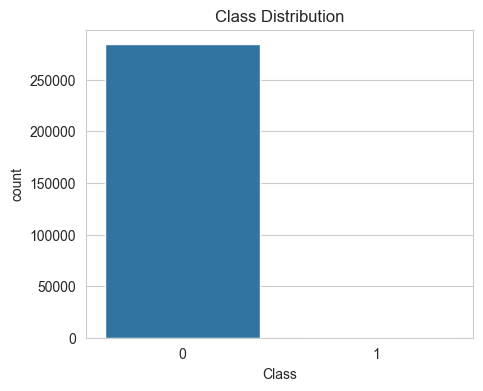

In [10]:
plt.figure(figsize=(5,4))
sns.countplot(x='Class',data=df)
plt.title("Class Distribution")
plt.show()

Observation:

The dataset contains 284315 transactions with 31 columns.Most features are pca-transformed.
The target varaible is 'Class' where:

0~Legitimate transaction
1~Fraudulent transaction


Distribution of Transaction Amount

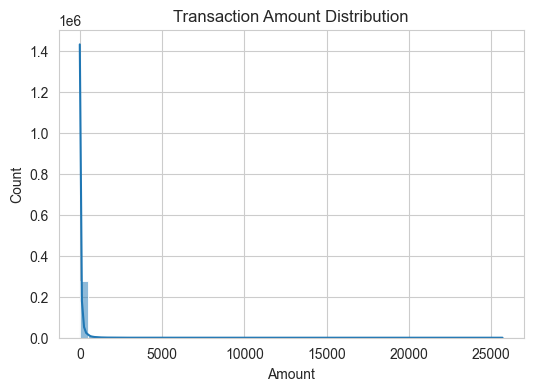

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df['Amount'],bins=50,kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

Distribution of Time Feature

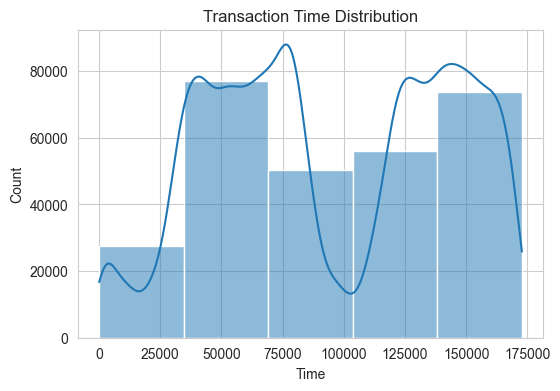

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df['Time'],bins=5,kde=True)
plt.title("Transaction Time Distribution")
plt.show()

 Fraud vs Non-Fraud Amount Comaprison

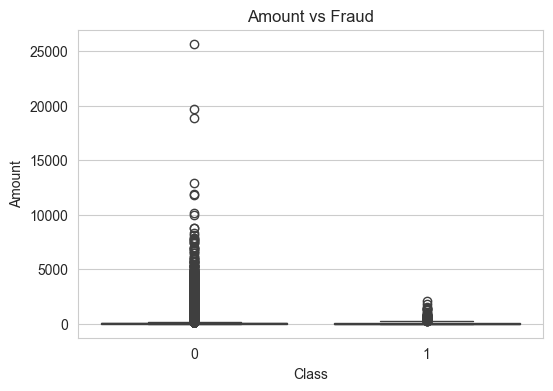

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Class',y='Amount',data=df)
plt.title("Amount vs Fraud")
plt.show()

Fraudulent transactions show a different distribution pattern compared to legitimate ones.
Although fraud cases are rare, some exhibit higher transaction amounts.

This suggests that 'Amount' may contribute predictive value.
However, since fraud patterns are complex, multiple features must be considered.

Correlation Analysis

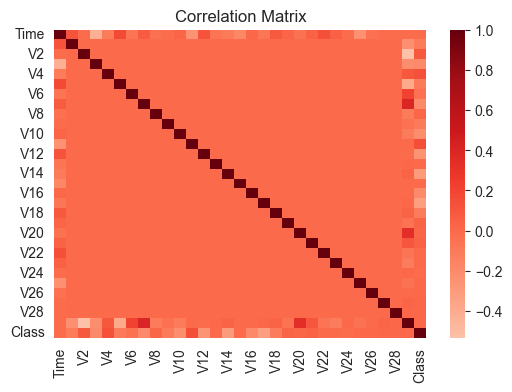

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(),cmap='Reds',center=0)
plt.title("Correlation Matrix")
plt.show()

Some PCA components show moderate correlation with target.

No severe multicollinearity issues visible.

# 📌 Final EDA Summary

Key Findings:

1. The dataset is highly imbalanced (~0.17% fraud cases).
2. There are no missing values.
3. The `Amount` feature is skewed and requires scaling.
4. The `Time` feature can be engineered into hour-based feature.
5. Accuracy is not a reliable metric for this problem.
6. Recall and ROC-AUC will be prioritized during model evaluation.

Next Steps:
- Feature engineering
- Train-test split (stratified)
- Apply imbalance handling techniques (SMOTE, class weights)
- Train and compare multiple models

## 🔹 1️⃣ Feature Engineering

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df = df.drop(['Amount'], axis=1)

## 🔹 2️⃣ Train-Test Split (Very Important: Stratified)

Because fraud is only ~0.17%, we MUST preserve class ratio

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## 🔹 3️⃣ Scaling Features

Since PCA features are already scaled, but Amount isn’t, scaling everything is safer:

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Instantiate the SMOTE algorithm
smote = SMOTE(random_state=42)
# Apply SMOTE only to the training data
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)


## 🔹 4️⃣ Logistic Regression(Handle Class Imbalance)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Logistic Regression with class balancing
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_log))

log_auc = roc_auc_score(y_test, y_prob_log)
print("ROC-AUC:", log_auc)

Logistic Regression Results
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9720834996210077


📊 1️⃣ Logistic Regression Analysis
Fraud Class (1):

Precision = 0.06

Recall = 0.92

F1-score = 0.11

What This Means:

✅ It detects 92% of fraud cases
❌ But precision is extremely low (6%)

That means:

For every 100 transactions predicted as fraud, only 6 are actually fraud.

So it generates many false alarms (FP).

## 🔹 Class Balancing using SMOTE

In [25]:
log_model_sm = LogisticRegression()
log_model_sm.fit(X_resampled, y_resampled)

y_pred_log_sm = log_model_sm.predict(X_test)
y_prob_log_sm = log_model_sm.predict_proba(X_test)[:,1]

print("Logistic Regression Results with SMOTE")
print(classification_report(y_test, y_pred_log_sm))

log_auc_sm = roc_auc_score(y_test, y_prob_log_sm)
print("ROC-AUC:", log_auc)

Logistic Regression Results with SMOTE
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9720834996210077


The performance of Logistic Regression with SMOTE remained similar to the class-weighted Logistic Regression model. This occurs because the class_weight='balanced' parameter already compensates for class imbalance by assigning higher penalties to minority class errors. Therefore, the additional oversampling from SMOTE did not significantly change the model's decision boundary, resulting in comparable performance metrics.

## 🔹 5️⃣  Random Forest Model

Why Random Forest?

Handles non-linearity

Not sensitive to scaling

Handles imbalance better with class_weigh

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))

rf_auc = roc_auc_score(y_test, y_prob_rf)
print("ROC-AUC:", rf_auc)

Random Forest Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9571936047913819


📊 2️⃣ Random Forest Analysis
Fraud Class (1):

Precision = 0.96

Recall = 0.76

F1-score = 0.85

What This Means:

✅ When it predicts fraud, it's correct 96% of the time
⚠️ It detects 76% of fraud cases (misses 24%)

Much better balance.

## Random Forest with SMOTE

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_resampled, y_resampled)

y_pred_rf_sm = rf_model.predict(X_test)
y_prob_rf_sm = rf_model.predict_proba(X_test)[:,1]

print("Random Forest Results with smote")
print(classification_report(y_test, y_pred_rf_sm))

rf_auc_sm = roc_auc_score(y_test, y_prob_rf_sm)
print("ROC-AUC:", rf_auc_sm)

Random Forest Results with smote
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9754173581362763


📊  Random Forest with smote Analysis 
Class 1 (Fraud transactions):

Precision = 0.89

Recall = 0.83

F1-score = 0.86

Meaning:

Precision 0.89

👉 When the model says “Fraud”, it is correct 89% of the time.
Very few false alarms.

Recall 0.83

👉 The model catches 83% of all fraud cases.

F1-score 0.86

👉 Good balance between catching fraud and avoiding false alarms.

## 🔹 6️⃣  Compare Metrics Properly

Let’s extract key numbers:

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = {
    "Model": ["Logistic Regression","Logistic Regression with smote" ,"Random Forest","Random Forest with smote"],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_log_sm),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_sm)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_sm)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_log_sm),
        f1_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_sm)
    ],
    "ROC-AUC": [
        log_auc,
        log_auc_sm,
        rf_auc,
        rf_auc_sm
    ]
}

import pandas as pd
comparison_df = pd.DataFrame(results)
comparison_df

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.060976,0.918367,0.114358,0.972083
1,Logistic Regression with smote,0.057803,0.918367,0.108761,0.970843
2,Random Forest,0.961039,0.755102,0.845714,0.957194
3,Random Forest with smote,0.890110,0.890110,0.890110,0.975417


Interesting:

Logistic Regression has slightly higher ROC-AUC
But Random Forest has MUCH better precision-recall tradeoff.

## 🔹 7  Plot ROC Curves Together

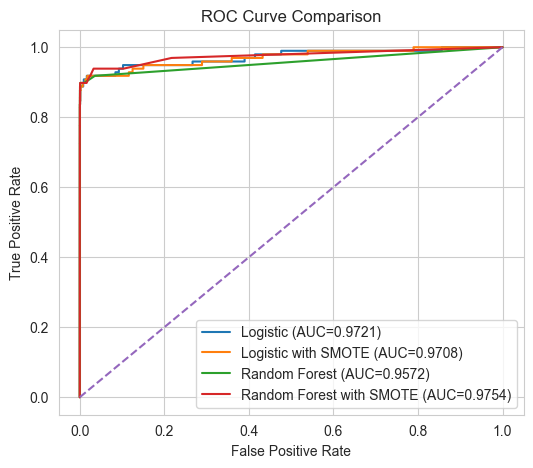

In [32]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_log_sm, tpr_log_sm, _ = roc_curve(y_test, y_prob_log_sm)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_rf_sm, tpr_rf_sm, _ = roc_curve(y_test, y_prob_rf_sm)

plt.figure(figsize=(6,5))
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC={log_auc:.4f})")
plt.plot(fpr_log_sm,tpr_log_sm, label=f"Logistic with SMOTE (AUC={log_auc_sm:.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_auc:.4f})")
plt.plot(fpr_rf_sm,tpr_rf_sm, label=f"Random Forest with SMOTE (AUC={rf_auc_sm:.4f})")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Model Comparison Analysis

Four models were evaluated for fraud detection: Logistic Regression, Logistic Regression with SMOTE, Random Forest, and Random Forest with SMOTE. Logistic Regression achieved a high recall (0.92) but very low precision (0.06), indicating that although most fraud cases were detected, the model produced a large number of false positives. Applying SMOTE to Logistic Regression did not significantly improve its performance, as the precision and recall remained nearly the same.

In contrast, Random Forest demonstrated significantly better performance with high precision (0.96) and a strong F1-score (0.85), indicating a better balance between detecting fraud and minimizing false alarms. When SMOTE was applied, Random Forest achieved the best overall performance with balanced precision and recall (0.89) and the highest ROC-AUC score (0.975). Therefore, Random Forest with SMOTE is selected as the optimal model for fraud detection due to its superior ability to detect fraudulent transactions while maintaining a low false positive rate.